In [1]:
import json
import pandas as pd
import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
eia_930_regions = gpd.read_file('../data/shapefiles/bas_and_subbas')

bas = (
    gpd.read_file('../data/shapefiles/Balancing_Authorities')
    .to_crs(eia_930_regions.crs)
)

with open('../config/rto_region_eia_code_map.json', 'r') as file:
    rto_region_id_eia_code_map = json.load(file)

rto_regions = (
    gpd.read_file('../data/shapefiles/RTO_Regions')
    .to_crs(eia_930_regions.crs)
)
rto_regions['EIAcode'] = rto_regions['Unique_ID'].map(rto_region_id_eia_code_map)
subbas = rto_regions.dropna(subset='EIAcode')
miso_new = subbas.loc[subbas.RTO_ISO == 'MISO'].dissolve(['EIAcode']).reset_index()
subbas = pd.concat([subbas.loc[subbas.RTO_ISO != 'MISO'], miso_new], ignore_index=True)

In [3]:
pnm_old = bas.loc[bas.EIAcode == 'PNM']
pnm_new = eia_930_regions.loc[eia_930_regions.EIAcode == 'PNM']

walc_old = bas.loc[bas.EIAcode == 'WALC']
walc_new = eia_930_regions.loc[eia_930_regions.EIAcode == 'WALC']

swpp_old = subbas.loc[subbas.RTO_ISO == 'SPP']
swpp_new = eia_930_regions.loc[eia_930_regions.EIAcode.isin(swpp_old.EIAcode)]

pjm_old = subbas.loc[subbas.RTO_ISO == 'PJM']
pjm_new = eia_930_regions.loc[eia_930_regions.EIAcode.isin(pjm_old.EIAcode)]

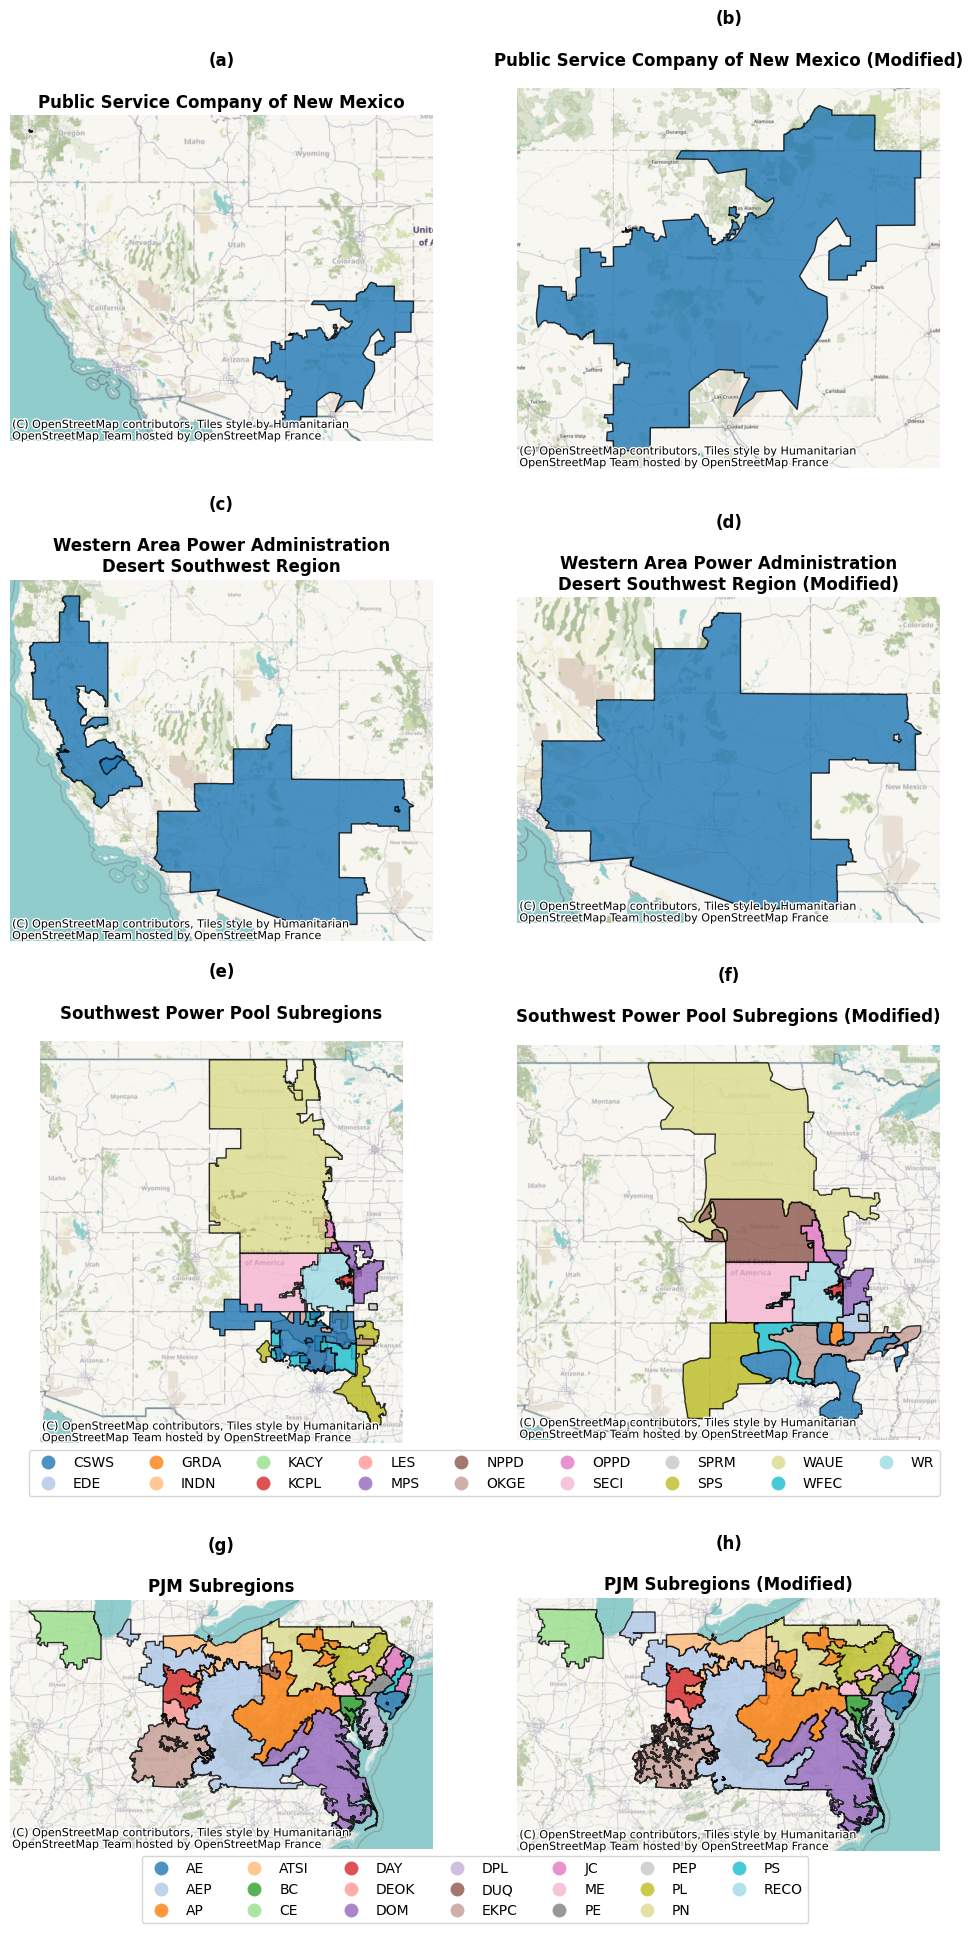

In [4]:
fig, ax = plt.subplots(4, 2, figsize=(12, 24))
fontsize = 12


## PNM
ax_ = ax[0,0]
gdf = pnm_old.copy().to_crs(epsg=3857)
gdf.plot(
    column='EIAcode',
    legend=False,
    legend_kwds={
        'loc': 'upper center',
        'bbox_to_anchor': (0.5, 0),
        'ncol':1
    },
    ax=ax_,
    edgecolor='black',
    alpha=0.8
)
ax_.set_title('(a)\n\nPublic Service Company of New Mexico', fontweight='bold', fontsize=fontsize)
ctx.add_basemap(ax_)
ax_.set_axis_off()

ax_ = ax[0,1]
gdf = pnm_new.copy().to_crs(epsg=3857)
gdf.plot(
    column='EIAcode',
    legend=False,
    legend_kwds={
        'loc': 'upper center',
        'bbox_to_anchor': (0.5, 0),
        'ncol':1
    },
    ax=ax_,
    edgecolor='black',
    alpha=0.8
)
ax_.set_title('(b)\n\nPublic Service Company of New Mexico (Modified)', fontweight='bold', fontsize=fontsize)
ctx.add_basemap(ax_)
ax_.set_axis_off()


## WALC
ax_ = ax[1,0]
gdf = walc_old.copy().to_crs(epsg=3857)
gdf.plot(
    column='EIAcode',
    legend=False,
    legend_kwds={
        'loc': 'upper center',
        'bbox_to_anchor': (0.5, 0),
        'ncol':1
    },
    ax=ax_,
    edgecolor='black',
    alpha=0.8
)
ax_.set_title('(c)\n\nWestern Area Power Administration\nDesert Southwest Region', fontweight='bold', fontsize=fontsize)
ctx.add_basemap(ax_)
ax_.set_axis_off()

ax_ = ax[1,1]
gdf = walc_new.copy().to_crs(epsg=3857)
gdf.plot(
    column='EIAcode',
    legend=False,
    legend_kwds={
        'loc': 'upper center',
        'bbox_to_anchor': (0.5, 0),
        'ncol':1
    },
    ax=ax_,
    edgecolor='black',
    alpha=0.8
)
ax_.set_title('(d)\n\nWestern Area Power Administration\nDesert Southwest Region (Modified)', fontweight='bold', fontsize=fontsize)
ctx.add_basemap(ax_)
ax_.set_axis_off()


## SWPP
ax_ = ax[2,0]

gdf_all_zones = bas.loc[bas.EIAcode == 'WACM'].copy().to_crs(epsg=3857)
gdf_all_zones.plot(ax=ax_, alpha=0)

gdf = swpp_old.copy().to_crs(epsg=3857)
gdf.plot(
    column='EIAcode',
    cmap='tab20',
    legend=True,
    legend_kwds={
        'loc': 'upper center',
        'bbox_to_anchor': (1.225, 0),
        'ncol':9
    },
    ax=ax_,
    edgecolor='black',
    alpha=0.8
)
ax_.set_title('(e)\n\nSouthwest Power Pool Subregions', fontweight='bold', fontsize=fontsize)
ctx.add_basemap(ax_)
ax_.set_axis_off()


ax_ = ax[2,1]

gdf_all_zones.plot(ax=ax_, alpha=0)

gdf = swpp_new.copy().to_crs(epsg=3857)
gdf.plot(
    column='EIAcode',
    cmap='tab20',
    legend=False,
    ax=ax_,
    edgecolor='black',
    alpha=0.8
)
ax_.set_title('(f)\n\nSouthwest Power Pool Subregions (Modified)', fontweight='bold', fontsize=fontsize)
ctx.add_basemap(ax_)
ax_.set_axis_off()


## PJM
ax_ = ax[3,0]
gdf = pjm_old.copy().to_crs(epsg=3857)
gdf.plot(
    column='EIAcode',
    cmap='tab20',
    legend=True,
    legend_kwds={
        'loc': 'upper center',
        'bbox_to_anchor': (1.1, 0),
        'ncol':7
    },
    ax=ax_,
    edgecolor='black',
    alpha=0.8
)
ax_.set_title('(g)\n\nPJM Subregions', fontweight='bold', fontsize=fontsize)
ctx.add_basemap(ax_)
ax_.set_axis_off()


ax_ = ax[3,1]
gdf = pjm_new.copy().to_crs(epsg=3857)
gdf.plot(
    column='EIAcode',
    cmap='tab20',
    legend=False,
    ax=ax_,
    edgecolor='black',
    alpha=0.8
)
ax_.set_title('(h)\n\nPJM Subregions (Modified)', fontweight='bold', fontsize=fontsize)
ctx.add_basemap(ax_)
ax_.set_axis_off()

# plt.show()
plt.savefig('created_and_modified_boundaries.png', dpi=300, bbox_inches='tight')